# **Тестирование на Параболе методов PyOD**

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 219.8/219.8 kB 8.0 MB/s eta 0:00:00


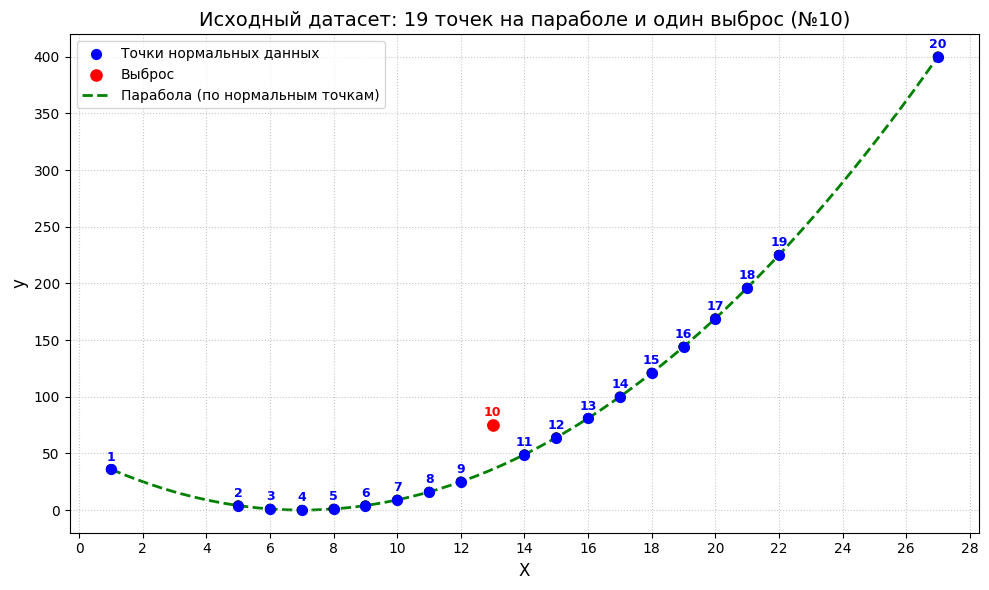

ABOD успешно обучен
HBOS успешно обучен
IsolationForest успешно обучен
kNN успешно обучен
LOF успешно обучен
OCSVM успешно обучен
PCA успешно обучен
SOS успешно обучен
COPOD успешно обучен

Все методы обучены.

РЕЗУЛЬТАТЫ ТЕСТИРОВАНИЯ МЕТОДОВ PyOD
                 Ранг истинного выброса  Обнаружил (label)  \
Метод                                                        
ABOD                                  4                  0   
HBOS                                 10                  0   
IsolationForest                      10                  0   
kNN                                  10                  0   
LOF                                   9                  0   
OCSVM                                20                  0   
PCA                                  15                  0   
SOS                                   3                  0   
COPOD                                17                  0   

                 Ложные срабатывания  
Метод                         

In [ ]:
import sys
!{sys.executable} -m pip install pyod

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Детекторы из библиотеки PyOD
from pyod.models import abod, hbos, iforest, knn, lof, ocsvm, pca, sos, copod

# ------------------------------------------------------------
# 1. Исходные данные: 20 точек, из которых 19 лежат на параболе,
#    а точка №10 (x=13, y=100) является выбросом.
# ------------------------------------------------------------
data = [
    (1, 1, 36), (2, 5, 4), (3, 6, 1), (4, 7, 0), (5, 8, 1),
    (6, 9, 4), (7, 10, 9), (8, 11, 16), (9, 12, 25), (10, 13, 75),
    (11, 14, 49), (12, 15, 64), (13, 16, 81), (14, 17, 100),
    (15, 18, 121), (16, 19, 144), (17, 20, 169), (18, 21, 196),
    (19, 22, 225), (20, 27, 400)
]

X = np.array([row[1] for row in data], dtype=np.float32).reshape(-1, 1)
y = np.array([row[2] for row in data], dtype=np.float32).reshape(-1, 1)

Q = X.shape[0]          # количество примеров = 20
outlier_idx = 9         # индекс истинного выброса (пример №10)

# ------------------------------------------------------------
# 2. Визуализация исходного датасета (до масштабирования)
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))

# Все точки (синие – нормальные, красный – выброс)
colors = ['red' if i == outlier_idx else 'blue' for i in range(Q)]
plt.scatter(X, y, c=colors, s=50, edgecolors='black', linewidth=0.5, zorder=5)
plt.scatter(X, y, color='blue', s=50, label='Точки нормальных данных', zorder=5)


# Заданный выброс (пример номер 10)
plt.scatter(X[outlier_idx], y[outlier_idx], color='red', s=50,
            linewidths=2, label='Выброс', zorder=5)

# Добавление номеров примеров
for i in range(Q):
    color = 'red' if i == outlier_idx else 'blue'
    plt.text(X[i, 0], y[i, 0] + 5, str(i+1), fontsize=9,
             ha='center', va='bottom', color=color, fontweight='bold')

# Аппроксимирующая парабола по точкам без выброса
good_mask = np.ones(Q, dtype=bool)
good_mask[outlier_idx] = False
X_good = X[good_mask].flatten()
y_good = y[good_mask].flatten()
coeffs = np.polyfit(X_good, y_good, 2)
poly = np.poly1d(coeffs)
X_smooth = np.linspace(X.min(), X.max(), 200)
y_smooth = poly(X_smooth)
plt.plot(X_smooth, y_smooth, 'g--', linewidth=2, label='Парабола (по нормальным точкам)', zorder=1)

plt.xlabel('X', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('Исходный датасет: 19 точек на параболе и один выброс (№10)', fontsize=14)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.xticks(np.arange(0, X.max()+2, 2))
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 3. Подготовка данных для детекторов PyOD
#    Детекторы работают в пространстве признаков (X, y).
#    Масштабирование необходимо для методов, основанных на расстояниях.
# ------------------------------------------------------------
X_2d = np.column_stack((X.flatten(), y.flatten()))   # матрица [X, y]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_2d)

# ------------------------------------------------------------
# 4. Определение детекторов с параметром contamination=0.1,
#    т.е. ожидается, что они отметят примерно 2 самых аномальных точки.
# ------------------------------------------------------------
detectors = {
    'ABOD': abod.ABOD(contamination=0.1),
    'HBOS': hbos.HBOS(contamination=0.1),
    'IsolationForest': iforest.IForest(contamination=0.1, random_state=42),
    'kNN': knn.KNN(contamination=0.1),
    'LOF': lof.LOF(contamination=0.1),
    'OCSVM': ocsvm.OCSVM(contamination=0.1),
    'PCA': pca.PCA(contamination=0.1),
    'SOS': sos.SOS(contamination=0.1),
    'COPOD': copod.COPOD(contamination=0.1)
}

# ------------------------------------------------------------
# 5. Обучение каждого детектора и сбор результатов
# ------------------------------------------------------------
results = {}
scores = {}

for name, model in detectors.items():
    try:
        model.fit(X_scaled)
        results[name] = model.labels_               # 1 – выброс, 0 – норма
        scores[name] = model.decision_scores_       # чем больше, тем аномальнее
        print(f"{name} успешно обучен")
    except Exception as e:
        print(f"Ошибка при обучении {name}: {e}")
        results[name] = np.zeros(Q, dtype=int) - 1
        scores[name] = np.zeros(Q) - 1

print("\nВсе методы обучены.\n")

# ------------------------------------------------------------
# 6. Формирование таблицы результатов для истинного выброса (пример №10)
# ------------------------------------------------------------
methods = list(detectors.keys())
ranks = []          # ранг истинного выброса (1 – самый аномальный)
detected = []       # 1 если метод пометил его как выброс, иначе 0
false_pos = []      # количество ложных срабатываний (нормальных точек, помеченных как выброс)

for name in methods:
    if np.all(results[name] == -1):   # метод не сработал
        ranks.append(-1)
        detected.append(-1)
        false_pos.append(-1)
    else:
        # Ранг: чем больше score, тем меньше ранг (1 – максимальный)
        rank = pd.Series(scores[name]).rank(ascending=False, method='min').astype(int).iloc[outlier_idx]
        ranks.append(rank)
        detected.append(results[name][outlier_idx])
        # Ложные срабатывания: все точки, кроме истинного выброса, с меткой 1
        fp = np.sum((results[name] == 1) & (np.arange(Q) != outlier_idx))
        false_pos.append(fp)

# Создаём DataFrame для наглядного вывода
df_results = pd.DataFrame({
    'Метод': methods,
    'Ранг истинного выброса': ranks,
    'Обнаружил (label)': detected,
    'Ложные срабатывания': false_pos
})
df_results.set_index('Метод', inplace=True)

print("="*80)
print("РЕЗУЛЬТАТЫ ТЕСТИРОВАНИЯ МЕТОДОВ PyOD")
print("="*80)
print(df_results)



# **То же на английском**

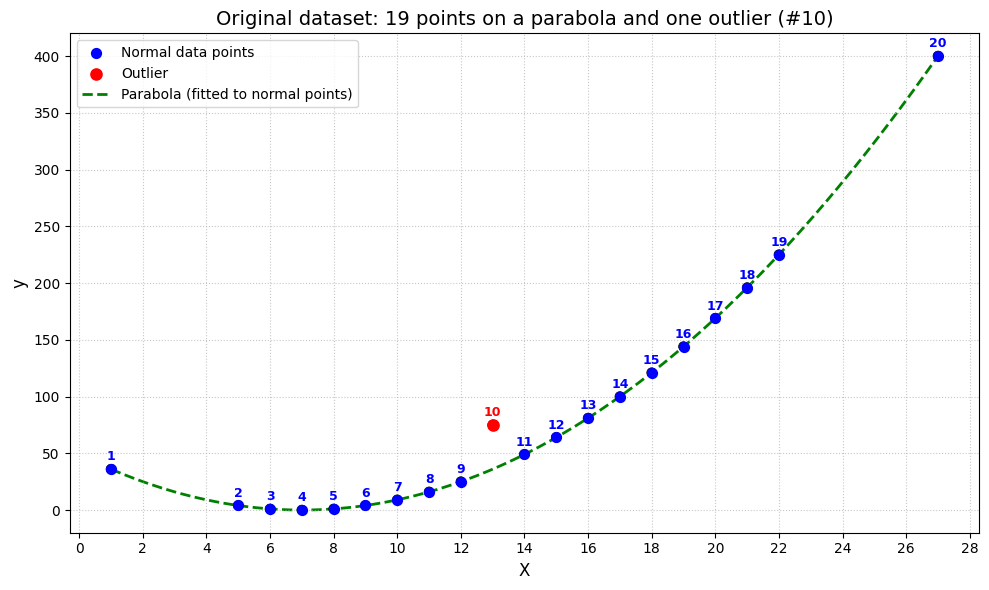

ABOD successfully trained
HBOS successfully trained
IsolationForest successfully trained
kNN successfully trained
LOF successfully trained
OCSVM successfully trained
PCA successfully trained
SOS successfully trained
COPOD successfully trained

All detectors have been trained.

RESULTS OF PyOD DETECTORS
                 Rank of true outlier  Detected (label)  False positives
Method                                                                  
ABOD                                4                 0                2
HBOS                               10                 0                2
IsolationForest                    10                 0                2
kNN                                10                 0                2
LOF                                 9                 0                2
OCSVM                              20                 0                2
PCA                                15                 0                2
SOS                                 3  

In [ ]:
import sys
!{sys.executable} -m pip install pyod

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Detectors from the PyOD library
from pyod.models import abod, hbos, iforest, knn, lof, ocsvm, pca, sos, copod

# ------------------------------------------------------------
# 1. Original data: 20 points, 19 of which lie on a parabola,
#    and point #10 (x=13, y=100) is an outlier.
# ------------------------------------------------------------
data = [
    (1, 1, 36), (2, 5, 4), (3, 6, 1), (4, 7, 0), (5, 8, 1),
    (6, 9, 4), (7, 10, 9), (8, 11, 16), (9, 12, 25), (10, 13, 75),
    (11, 14, 49), (12, 15, 64), (13, 16, 81), (14, 17, 100),
    (15, 18, 121), (16, 19, 144), (17, 20, 169), (18, 21, 196),
    (19, 22, 225), (20, 27, 400)
]

X = np.array([row[1] for row in data], dtype=np.float32).reshape(-1, 1)
y = np.array([row[2] for row in data], dtype=np.float32).reshape(-1, 1)

Q = X.shape[0]          # number of samples = 20
outlier_idx = 9         # index of the true outlier (sample #10)

# ------------------------------------------------------------
# 2. Visualization of the original dataset (before scaling)
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))

# All points (blue – normal, red – outlier)
colors = ['red' if i == outlier_idx else 'blue' for i in range(Q)]
plt.scatter(X, y, c=colors, s=50, edgecolors='black', linewidth=0.5, zorder=5)
plt.scatter(X, y, color='blue', s=50, label='Normal data points', zorder=5)

# Specified outlier (sample #10)
plt.scatter(X[outlier_idx], y[outlier_idx], color='red', s=50,
            linewidths=2, label='Outlier', zorder=5)

# Add sample numbers
for i in range(Q):
    color = 'red' if i == outlier_idx else 'blue'
    plt.text(X[i, 0], y[i, 0] + 5, str(i+1), fontsize=9,
             ha='center', va='bottom', color=color, fontweight='bold')

# Parabola fitted to the normal points (excluding the outlier)
good_mask = np.ones(Q, dtype=bool)
good_mask[outlier_idx] = False
X_good = X[good_mask].flatten()
y_good = y[good_mask].flatten()
coeffs = np.polyfit(X_good, y_good, 2)
poly = np.poly1d(coeffs)
X_smooth = np.linspace(X.min(), X.max(), 200)
y_smooth = poly(X_smooth)
plt.plot(X_smooth, y_smooth, 'g--', linewidth=2, label='Parabola (fitted to normal points)', zorder=1)

plt.xlabel('X', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('Original dataset: 19 points on a parabola and one outlier (#10)', fontsize=14)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.xticks(np.arange(0, X.max()+2, 2))
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 3. Prepare data for PyOD detectors
#    Detectors work in the feature space (X, y).
#    Scaling is necessary for distance‑based methods.
# ------------------------------------------------------------
X_2d = np.column_stack((X.flatten(), y.flatten()))   # matrix [X, y]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_2d)

# ------------------------------------------------------------
# 4. Define detectors with contamination=0.1,
#    i.e., they are expected to mark approximately the two most anomalous points.
# ------------------------------------------------------------
detectors = {
    'ABOD': abod.ABOD(contamination=0.1),
    'HBOS': hbos.HBOS(contamination=0.1),
    'IsolationForest': iforest.IForest(contamination=0.1, random_state=42),
    'kNN': knn.KNN(contamination=0.1),
    'LOF': lof.LOF(contamination=0.1),
    'OCSVM': ocsvm.OCSVM(contamination=0.1),
    'PCA': pca.PCA(contamination=0.1),
    'SOS': sos.SOS(contamination=0.1),
    'COPOD': copod.COPOD(contamination=0.1)
}

# ------------------------------------------------------------
# 5. Train each detector and collect the results
# ------------------------------------------------------------
results = {}
scores = {}

for name, model in detectors.items():
    try:
        model.fit(X_scaled)
        results[name] = model.labels_               # 1 – outlier, 0 – inlier
        scores[name] = model.decision_scores_       # larger score means more anomalous
        print(f"{name} successfully trained")
    except Exception as e:
        print(f"Error training {name}: {e}")
        results[name] = np.zeros(Q, dtype=int) - 1
        scores[name] = np.zeros(Q) - 1

print("\nAll detectors have been trained.\n")

# ------------------------------------------------------------
# 6. Build a result table for the true outlier (sample #10)
# ------------------------------------------------------------
methods = list(detectors.keys())
ranks = []          # rank of the true outlier (1 = most anomalous)
detected = []       # 1 if the method flagged it as outlier, else 0
false_pos = []      # number of false positives (normal points flagged as outliers)

for name in methods:
    if np.all(results[name] == -1):   # method failed
        ranks.append(-1)
        detected.append(-1)
        false_pos.append(-1)
    else:
        # Rank: larger score yields smaller rank (1 is maximum)
        rank = pd.Series(scores[name]).rank(ascending=False, method='min').astype(int).iloc[outlier_idx]
        ranks.append(rank)
        detected.append(results[name][outlier_idx])
        # False positives: all points except the true outlier that have label 1
        fp = np.sum((results[name] == 1) & (np.arange(Q) != outlier_idx))
        false_pos.append(fp)

# Create a DataFrame for clear presentation
df_results = pd.DataFrame({
    'Method': methods,
    'Rank of true outlier': ranks,
    'Detected (label)': detected,
    'False positives': false_pos
})
df_results.set_index('Method', inplace=True)

print("="*80)
print("RESULTS OF PyOD DETECTORS")
print("="*80)
print(df_results)

# **!1  С выдачей списка неверно обнаруженных выбросов**

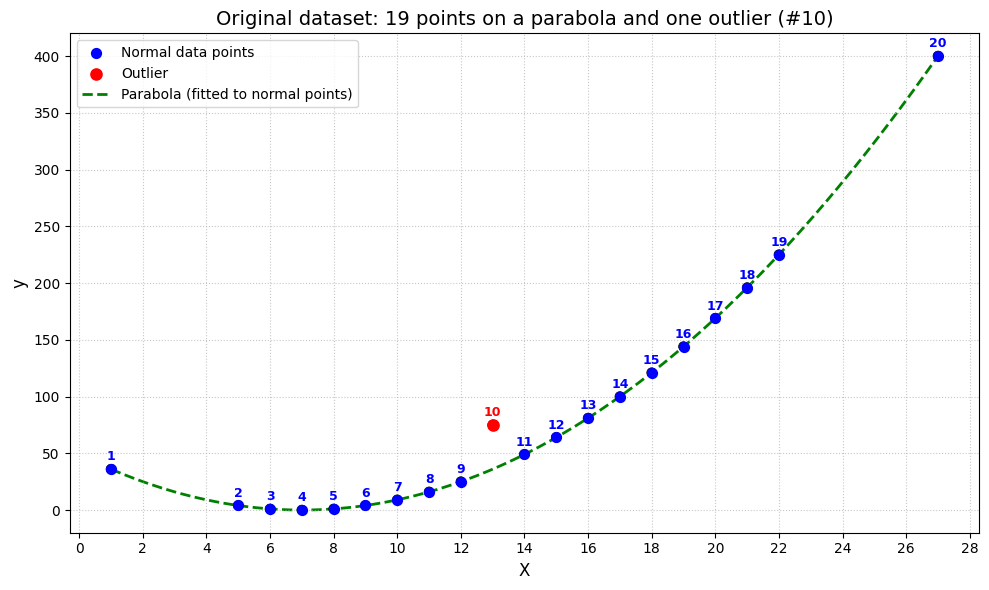

ABOD successfully trained
HBOS successfully trained
IsolationForest successfully trained
kNN successfully trained
LOF successfully trained
OCSVM successfully trained
PCA successfully trained
SOS successfully trained
COPOD successfully trained

All detectors have been trained.

RESULTS OF PyOD DETECTORS
                 Rank of true outlier  Detected (label)  False positives  \
Method                                                                     
ABOD                                4                 0                2   
HBOS                               10                 0                2   
IsolationForest                    10                 0                2   
kNN                                10                 0                2   
LOF                                 9                 0                2   
OCSVM                              20                 0                2   
PCA                                15                 0                2   
SOS         

In [ ]:
import sys
!{sys.executable} -m pip install pyod

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Detectors from the PyOD library
from pyod.models import abod, hbos, iforest, knn, lof, ocsvm, pca, sos, copod

# ------------------------------------------------------------
# 1. Original data: 20 points, 19 of which lie on a parabola,
#    and point #10 (x=13, y=100) is an outlier.
# ------------------------------------------------------------
data = [
    (1, 1, 36), (2, 5, 4), (3, 6, 1), (4, 7, 0), (5, 8, 1),
    (6, 9, 4), (7, 10, 9), (8, 11, 16), (9, 12, 25), (10, 13, 75),
    (11, 14, 49), (12, 15, 64), (13, 16, 81), (14, 17, 100),
    (15, 18, 121), (16, 19, 144), (17, 20, 169), (18, 21, 196),
    (19, 22, 225), (20, 27, 400)
]

X = np.array([row[1] for row in data], dtype=np.float32).reshape(-1, 1)
y = np.array([row[2] for row in data], dtype=np.float32).reshape(-1, 1)

Q = X.shape[0]          # number of samples = 20
outlier_idx = 9         # index of the true outlier (sample #10)

# ------------------------------------------------------------
# 2. Visualization of the original dataset (before scaling)
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))

# All points (blue – normal, red – outlier)
colors = ['red' if i == outlier_idx else 'blue' for i in range(Q)]
plt.scatter(X, y, c=colors, s=50, edgecolors='black', linewidth=0.5, zorder=5)
plt.scatter(X, y, color='blue', s=50, label='Normal data points', zorder=5)

# Specified outlier (sample #10)
plt.scatter(X[outlier_idx], y[outlier_idx], color='red', s=50,
            linewidths=2, label='Outlier', zorder=5)

# Add sample numbers
for i in range(Q):
    color = 'red' if i == outlier_idx else 'blue'
    plt.text(X[i, 0], y[i, 0] + 5, str(i+1), fontsize=9,
             ha='center', va='bottom', color=color, fontweight='bold')

# Parabola fitted to the normal points (excluding the outlier)
good_mask = np.ones(Q, dtype=bool)
good_mask[outlier_idx] = False
X_good = X[good_mask].flatten()
y_good = y[good_mask].flatten()
coeffs = np.polyfit(X_good, y_good, 2)
poly = np.poly1d(coeffs)
X_smooth = np.linspace(X.min(), X.max(), 200)
y_smooth = poly(X_smooth)
plt.plot(X_smooth, y_smooth, 'g--', linewidth=2, label='Parabola (fitted to normal points)', zorder=1)

plt.xlabel('X', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('Original dataset: 19 points on a parabola and one outlier (#10)', fontsize=14)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.xticks(np.arange(0, X.max()+2, 2))
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 3. Prepare data for PyOD detectors
#    Detectors work in the feature space (X, y).
#    Scaling is necessary for distance‑based methods.
# ------------------------------------------------------------
X_2d = np.column_stack((X.flatten(), y.flatten()))   # matrix [X, y]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_2d)

# ------------------------------------------------------------
# 4. Define detectors with contamination=0.1,
#    i.e., they are expected to mark approximately the two most anomalous points.
# ------------------------------------------------------------
detectors = {
    'ABOD': abod.ABOD(contamination=0.1),
    'HBOS': hbos.HBOS(contamination=0.1),
    'IsolationForest': iforest.IForest(contamination=0.1, random_state=42),
    'kNN': knn.KNN(contamination=0.1),
    'LOF': lof.LOF(contamination=0.1),
    'OCSVM': ocsvm.OCSVM(contamination=0.1),
    'PCA': pca.PCA(contamination=0.1),
    'SOS': sos.SOS(contamination=0.1),
    'COPOD': copod.COPOD(contamination=0.1)
}

# ------------------------------------------------------------
# 5. Train each detector and collect the results
# ------------------------------------------------------------
results = {}
scores = {}

for name, model in detectors.items():
    try:
        model.fit(X_scaled)
        results[name] = model.labels_               # 1 – outlier, 0 – inlier
        scores[name] = model.decision_scores_       # larger score means more anomalous
        print(f"{name} successfully trained")
    except Exception as e:
        print(f"Error training {name}: {e}")
        results[name] = np.zeros(Q, dtype=int) - 1
        scores[name] = np.zeros(Q) - 1

print("\nAll detectors have been trained.\n")

# ------------------------------------------------------------
# 6. Build a result table for each method,
#    including the list of points flagged as outliers.
# ------------------------------------------------------------
methods = list(detectors.keys())
ranks = []          # rank of the true outlier (1 = most anomalous)
detected = []       # 1 if the method flagged it as outlier, else 0
false_pos = []      # number of false positives (normal points flagged as outliers)
outlier_lists = []  # list of point numbers flagged as outliers

for name in methods:
    if np.all(results[name] == -1):   # method failed
        ranks.append(-1)
        detected.append(-1)
        false_pos.append(-1)
        outlier_lists.append("Error")
    else:
        # Rank: larger score yields smaller rank (1 is maximum)
        rank = pd.Series(scores[name]).rank(ascending=False, method='min').astype(int).iloc[outlier_idx]
        ranks.append(rank)
        detected.append(results[name][outlier_idx])
        # False positives: all points except the true outlier that have label 1
        fp = np.sum((results[name] == 1) & (np.arange(Q) != outlier_idx))
        false_pos.append(fp)
        # List of all points flagged as outliers (1‑based indices)
        outlier_inds = np.where(results[name] == 1)[0] + 1
        outlier_lists.append(list(outlier_inds))

# Create a DataFrame for clear presentation
df_results = pd.DataFrame({
    'Method': methods,
    'Rank of true outlier': ranks,
    'Detected (label)': detected,
    'False positives': false_pos,
    'Outlier indices': outlier_lists
})
df_results.set_index('Method', inplace=True)

print("="*80)
print("RESULTS OF PyOD DETECTORS")
print("="*80)
print(df_results)

